# 01 - Exploratory Data Analysis (EDA)

Mục tiêu: hiểu dữ liệu và các pattern liên quan đến `Late_delivery_risk` **không dùng leakage features**.

## SECTION 1: Setup & Load Data

In [2]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

TARGET = 'Late_delivery_risk'

candidate_paths = [
    Path('dataset/DataCoSupplyChainDataset.csv'),
    Path('../dataset/DataCoSupplyChainDataset.csv'),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Cannot find DataCoSupplyChainDataset.csv from current working directory.')

print(f'Using dataset path: {DATA_PATH.resolve()}')

try:
    df = pd.read_csv(DATA_PATH, encoding='cp1252')
except UnicodeDecodeError:
    df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print()
print('Data types:')
print(df.dtypes)

print()
print('Missing values (descending):')
print(df.isnull().sum().sort_values(ascending=False))

print()
print('Target distribution (count):')
print(df[TARGET].value_counts())
print('Target distribution (ratio):')
print(df[TARGET].value_counts(normalize=True))

Using dataset path: /Users/nguyentran0703/Downloads/AIO_Conquer_warm_up_02/dataset/DataCoSupplyChainDataset.csv
Shape: (180519, 53)

Data types:
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      

## SECTION 2: Target Distribution

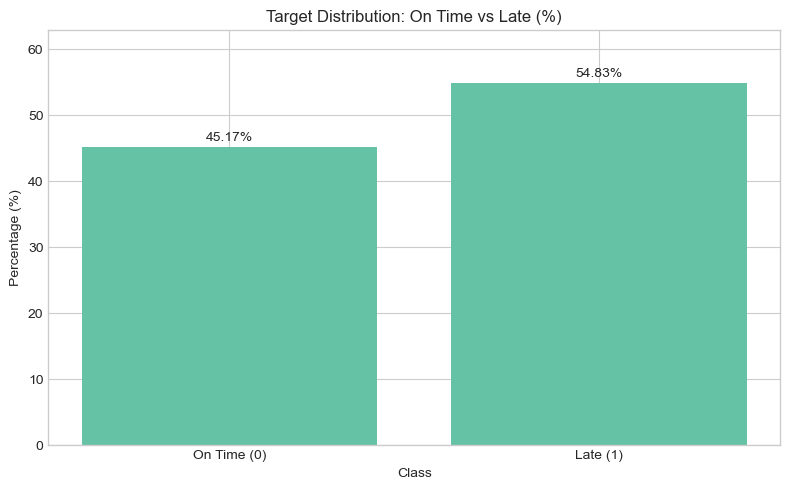

Class imbalance ratio: 54.83%


In [3]:
target_ratio = df[TARGET].value_counts(normalize=True).sort_index() * 100
labels = ['On Time (0)', 'Late (1)']
values = [target_ratio.get(0, 0), target_ratio.get(1, 0)]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.title('Target Distribution: On Time vs Late (%)')
plt.xlabel('Class')
plt.ylabel('Percentage (%)')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h:.2f}%', ha='center', va='bottom')

plt.ylim(0, max(values) + 8)
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {target_ratio.get(1, 0):.2f}%")

## SECTION 3: Shipping Mode Analysis

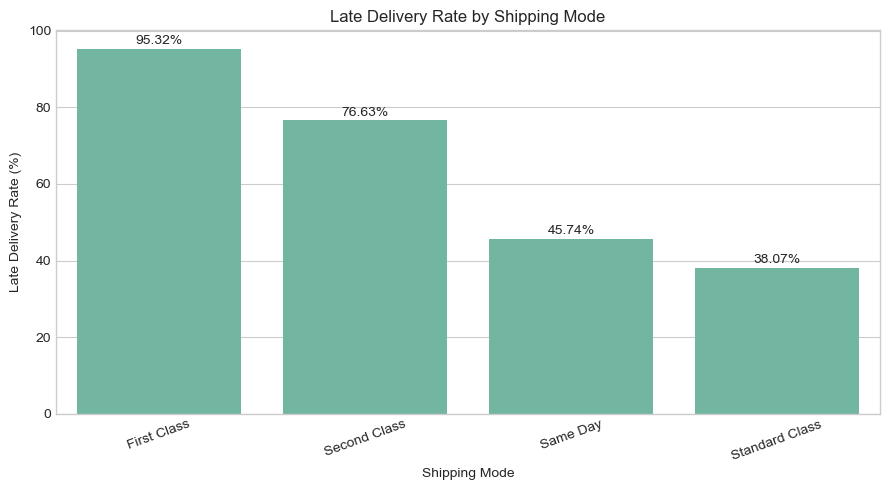

Highest-risk shipping mode: First Class (95.32% late rate)


In [4]:
shipping_late_rate = (
    df.groupby('Shipping Mode')[TARGET]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=shipping_late_rate.index, y=shipping_late_rate.values)
plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=20)

for i, v in enumerate(shipping_late_rate.values):
    ax.text(i, v + 0.4, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

highest_mode = shipping_late_rate.index[0]
highest_value = shipping_late_rate.iloc[0]
print(f'Highest-risk shipping mode: {highest_mode} ({highest_value:.2f}% late rate)')

## SECTION 4: Geographic Analysis

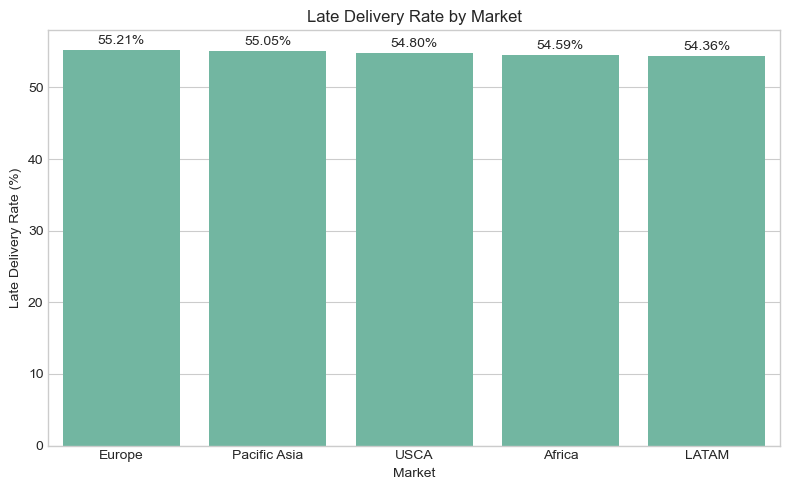

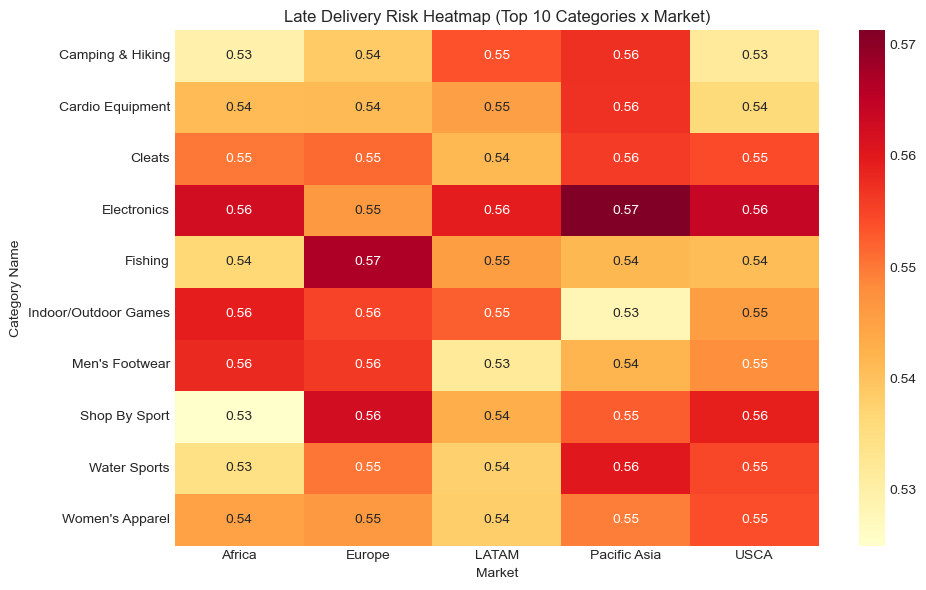

In [5]:
market_late_rate = df.groupby('Market')[TARGET].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=market_late_rate.index, y=market_late_rate.values)
plt.title('Late Delivery Rate by Market')
plt.xlabel('Market')
plt.ylabel('Late Delivery Rate (%)')

for i, v in enumerate(market_late_rate.values):
    ax.text(i, v + 0.4, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

top_categories = df['Category Name'].value_counts().head(10).index
heat_df = df[df['Category Name'].isin(top_categories)].copy()

pivot_table = heat_df.pivot_table(
    index='Category Name',
    columns='Market',
    values=TARGET,
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Late Delivery Risk Heatmap (Top 10 Categories x Market)')
plt.xlabel('Market')
plt.ylabel('Category Name')
plt.tight_layout()
plt.show()

## SECTION 5: Time Analysis

In [ ]:
df['order_date_parsed'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['Month'] = df['order_date_parsed'].dt.month
df['Day_of_Week'] = df['order_date_parsed'].dt.dayofweek

monthly_late = df.groupby('Month')[TARGET].mean() * 100
overall_avg = df[TARGET].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(monthly_late.index, monthly_late.values, marker='o')
plt.axhline(y=overall_avg, color='gray', linestyle='--', linewidth=1, label=f'Overall avg ({overall_avg:.2f}%)')
plt.title('Late Delivery Rate by Month')
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(range(1, 13))
plt.ylim(50, 60)
plt.legend()
plt.tight_layout()
plt.show()

print('Late rate by month:')
for m, rate in monthly_late.items():
    marker = ' ← above avg' if rate > overall_avg else ''
    print(f'  Month {m:2d}: {rate:.2f}%{marker}')
print(f'\nNote: Oct-Dec (months 10-12) do NOT show elevated late rates in this dataset.')
print(f'Months above average: {[m for m, r in monthly_late.items() if r > overall_avg]}')

dow_late = df.groupby('Day_of_Week')[TARGET].mean() * 100

dow_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=dow_late.index, y=dow_late.values)
plt.title('Late Delivery Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(ticks=list(dow_late.index), labels=[dow_labels[i] for i in dow_late.index])

for i, v in enumerate(dow_late.values):
    ax.text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## SECTION 6: Scheduled Days vs Late Risk

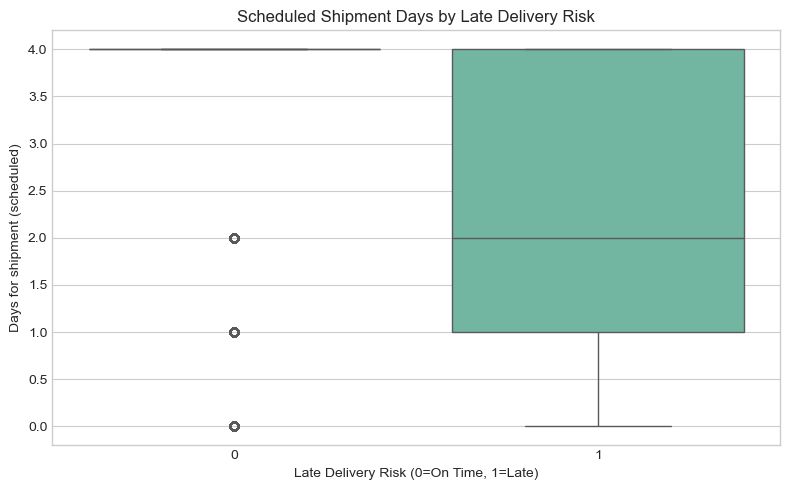

                        mean  50%       std
Late_delivery_risk                         
0                   3.491146  4.0  1.151072
1                   2.471069  2.0  1.372540

Quick note: Compare median/mean scheduled days for class 0 vs 1 to assess relationship.


In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=TARGET, y='Days for shipment (scheduled)', data=df)
plt.title('Scheduled Shipment Days by Late Delivery Risk')
plt.xlabel('Late Delivery Risk (0=On Time, 1=Late)')
plt.ylabel('Days for shipment (scheduled)')
plt.tight_layout()
plt.show()

summary = df.groupby(TARGET)['Days for shipment (scheduled)'].describe()[['mean', '50%', 'std']]
print(summary)
print()
print('Quick note: Compare median/mean scheduled days for class 0 vs 1 to assess relationship.')

## SECTION 7: Correlation Heatmap

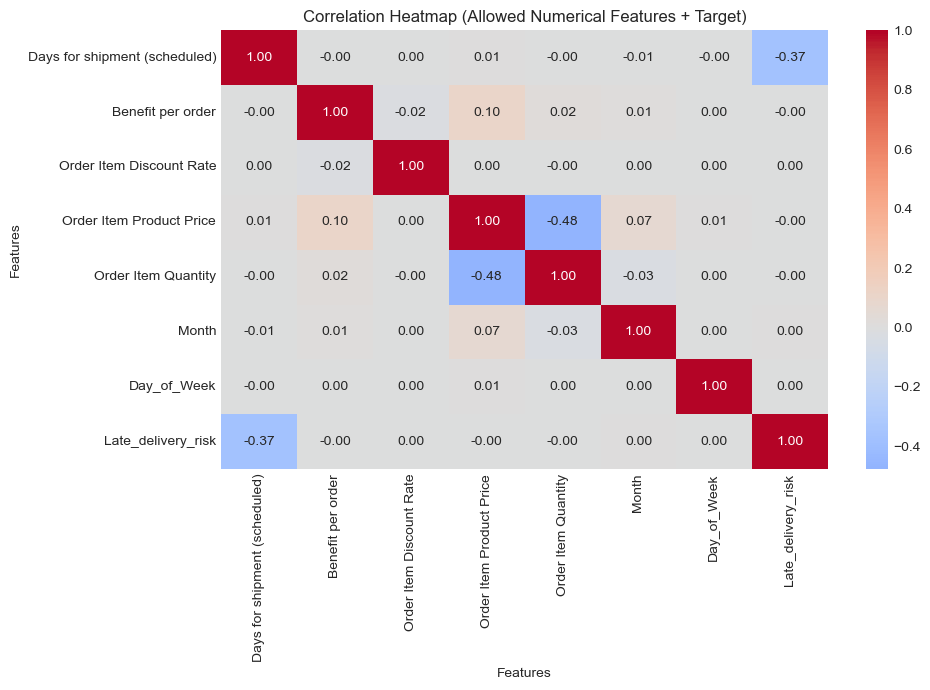

In [8]:
corr_cols = [
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Month',
    'Day_of_Week',
    TARGET,
]

corr_df = df[corr_cols].copy()
correlation_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Allowed Numerical Features + Target)')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## SECTION 8: EDA Summary

1. `Late_delivery_risk` có phân phối tương đối cân bằng nhưng nghiêng về lớp `Late` (~54.83%), nên khi train cần theo dõi Recall cho lớp 1 sát hơn Accuracy.
2. `Shipping Mode` cho thấy mức rủi ro trễ khác nhau rõ rệt giữa các nhóm, đây là feature categorical quan trọng cho mô hình phân loại.
3. Theo `Market` và ma trận `Category Name × Market`, rủi ro trễ biến thiên theo vùng và nhóm sản phẩm, gợi ý có tương tác địa lý-ngành hàng.
4. Yếu tố thời gian (Month/Day of Week) có biến động nhẹ theo chu kỳ, nhưng **không có seasonality rõ ràng theo tháng** — late rate dao động đồng đều ~54–56% quanh năm. Oct-Dec không phải peak season trong dataset này (dataset B2B supply chain, không phải B2C retail). Feature `Is_Peak_Season` được giữ lại trong pipeline nhưng có importance rất thấp (rank 13/13).
5. Các biến số lượng như `Days for shipment (scheduled)`, `Benefit per order`, `Order Item Discount Rate` có tương quan với target, phù hợp để đưa vào pipeline modeling kế tiếp.